# Coursera Courses

#### The objective of this analysis is to clean the dataset, perform exploratory data analysis, and identify potential areas for improvement. The workflow begins with importing the required libraries and loading the dataset using pandas. 
#### Data cleaning steps include handling missing and duplicate values. Finally, the dataset is analyzed to explore relationships and correlations between variables.

### Import Libraries

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt 
import plotly.express as px


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
print("Setup is complete!")

/kaggle/input/coursera-course-dataset/coursea_data.csv
Setup is complete!


## Load dataset

In [2]:
df = pd.read_csv('/kaggle/input/coursera-course-dataset/coursea_data.csv',index_col=0)

df.head()

,course_title,course_organization,course_Certificate_type,course_rating,course_difficulty,course_students_enrolled
134,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5.3k
743,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17k
874,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130k
413,A Law Student's Toolkit,Yale University,COURSE,4.7,Mixed,91k
635,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320k


The first column of the dataset represents unique course identifiers. Therefore, the parameter index_col=0 was used when loading the dataset to instruct pandas to treat the first column as the index rather than as a regular data column.

# Cleaning data

### Check null values

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 134 to 163
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   course_title              891 non-null    object 
 1   course_organization       891 non-null    object 
 2   course_Certificate_type   891 non-null    object 
 3   course_rating             891 non-null    float64
 4   course_difficulty         891 non-null    object 
 5   course_students_enrolled  891 non-null    object 
dtypes: float64(1), object(5)
memory usage: 48.7+ KB


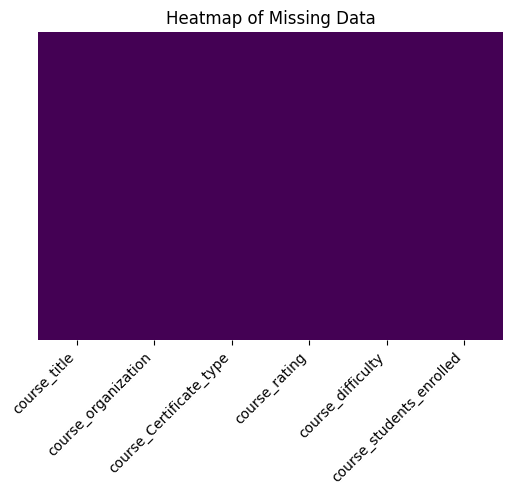

In [3]:
missing_data =df.isnull()

plt.figure(figsize=(6,4))
sns.heatmap(missing_data, cbar=False, cmap='viridis', yticklabels=False)
plt.title('Heatmap of Missing Data')
plt.xticks(rotation=45, ha="right")

df.shape
df.info()
df.describe()

plt.show()


No fully duplicated rows were found in the dataset. As a next step, the dataset was examined to determine whether any courses share the same title.

### Duplicated Values

In [4]:
df.duplicated().sum()
df[df.duplicated()]

,course_title,course_organization,course_Certificate_type,course_rating,course_difficulty,course_students_enrolled


There is no absolutely same values in our table, let's see if there is any courses with same title

### Duplicated Courses

In [5]:
df["course_title"].duplicated().sum()
df[df["course_title"].duplicated(keep=False)].sort_values("course_title")

,course_title,course_organization,course_Certificate_type,course_rating,course_difficulty,course_students_enrolled
756,Developing Your Musicianship,Berklee College of Music,COURSE,4.8,Mixed,41k
205,Developing Your Musicianship,Berklee College of Music,SPECIALIZATION,4.8,Beginner,54k
181,Machine Learning,University of Washington,SPECIALIZATION,4.6,Intermediate,290k
6,Machine Learning,Stanford University,COURSE,4.9,Mixed,3.2m
241,Marketing Digital,Universidade de São Paulo,COURSE,4.8,Beginner,81k
325,Marketing Digital,Universidad Austral,SPECIALIZATION,4.7,Beginner,39k


As we can see there are few courses with same titles, but they are not from same organization and that is why they are not considered as duplicated values.

## Adjusting Dtype of course_students_enrolled column

In [6]:
def parse_students(x):
    if pd.isna(x):
        return np.nan
    
    if isinstance(x, (int, float)):
        return float(x)

    x = str(x).strip().lower()
    
    if x.endswith("k"):
        return float(x[:-1]) * 1_000
    elif x.endswith("m"):
        return float(x[:-1]) * 1_000_000
    else:
        return float(x)



df["course_students_enrolled"] = df["course_students_enrolled"].apply(parse_students)

df.dtypes

df

,course_title,course_organization,course_Certificate_type,course_rating,course_difficulty,course_students_enrolled
134,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5300.0
743,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17000.0
874,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130000.0
413,A Law Student's Toolkit,Yale University,COURSE,4.7,Mixed,91000.0
635,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320000.0
...,...,...,...,...,...,...
236,Программирование на Python,Mail.Ru Group,SPECIALIZATION,4.5,Intermediate,52000.0
883,Психолингвистика (Psycholinguistics),Saint Petersburg State University,COURSE,4.8,Mixed,21000.0
545,Разработка интерфейсов: вёрстка и JavaScript,E-Learning Development Fund,SPECIALIZATION,4.5,Intermediate,30000.0
875,Русский как иностранный,Saint Petersburg State University,SPECIALIZATION,4.6,Intermediate,9800.0


Previously, it was observed that the values in the last column were stored as object types, represented by strings such as “5k” and “10m”. To enable numerical analysis, these values were converted into their corresponding numeric representations by applying appropriate scaling logic, and the column’s data type was subsequently converted to a floating-point format.

## Correlation of Numerical Columns

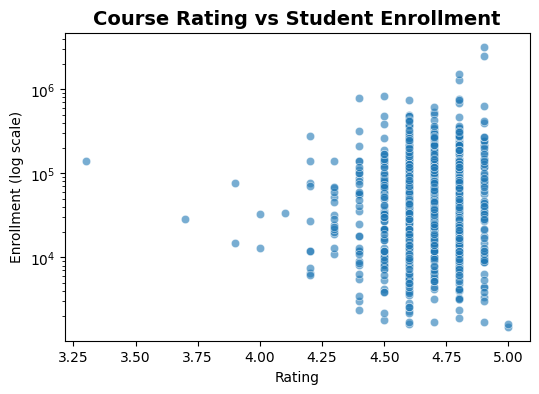

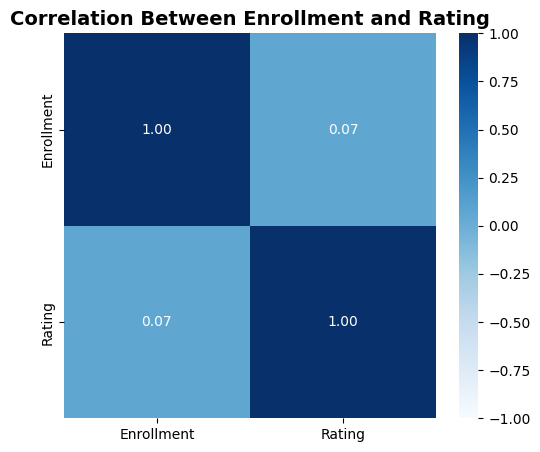

In [7]:
corr_data = df[["course_students_enrolled", "course_rating"]].rename(
    columns={
        "course_students_enrolled": "Enrollment",
        "course_rating": "Rating"
    }
)

corr_matrix = corr_data.corr()


plt.figure(figsize=(6,4))
sns.scatterplot(
    x="Rating",
    y="Enrollment",
    data=corr_data,
    alpha=0.6
)

plt.yscale("log")
plt.title("Course Rating vs Student Enrollment",fontsize=14, fontweight='bold')
plt.xlabel("Rating")
plt.ylabel("Enrollment (log scale)")
plt.show()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=-1, vmax=1
)

plt.title("Correlation Between Enrollment and Rating",fontsize=14, fontweight='bold')
plt.show()



The scatter plot shows a weak relationship between course ratings and student enrollment. While higher-rated courses are present among highly enrolled offerings, many courses with similar ratings attract significantly fewer students. This suggests that course popularity is influenced by factors beyond rating alone, such as course topic, provider reputation, and certification value.

## Analysis of Course Ratings

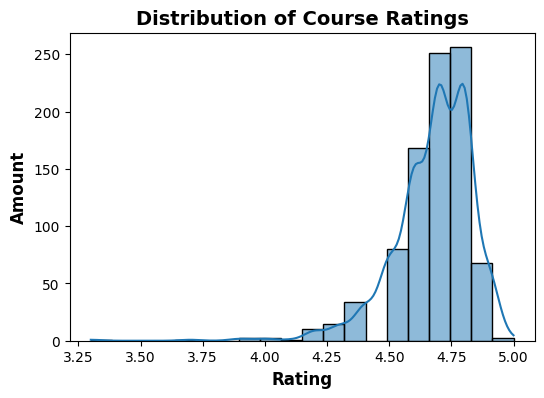

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(df["course_rating"], bins=20, kde=True)
plt.title("Distribution of Course Ratings",fontsize=14, fontweight='bold')
plt.xlabel("Rating",fontsize=12, fontweight='bold')
plt.ylabel("Amount",fontsize=12, fontweight='bold')
plt.show()

The histogram illustrates the distribution of course ratings in the dataset. The ratings are heavily concentrated between approximately 4.3 and 4.9, indicating that most courses receive relatively high evaluations. The kernel density estimate further highlights a strong peak around the upper end of the rating scale, suggesting that Coursera courses are generally well-rated by learners. Very few courses exhibit low ratings, which implies a limited presence of poorly perceived offerings on the platform.

# Course Popularity

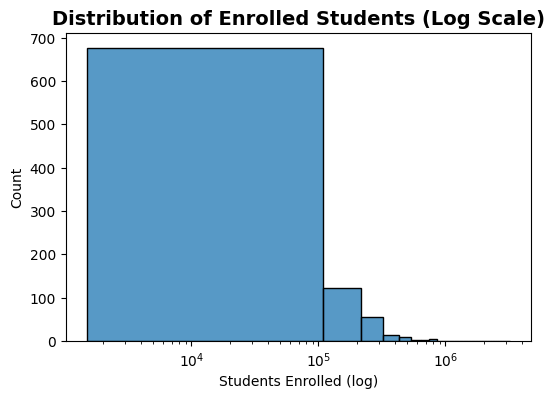

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df["course_students_enrolled"], bins=30)
plt.xscale("log")
plt.title("Distribution of Enrolled Students (Log Scale)",fontsize=14, fontweight='bold')
plt.xlabel("Students Enrolled (log)")
plt.ylabel("Count")
plt.show()


The distribution of enrolled students is highly right-skewed, with most courses enrolling tens of thousands of students, while a small number attract hundreds of thousands or millions. A logarithmic scale was used to better visualize this long-tail distribution and reveal meaningful patterns that would be obscured on a linear scale

# Worst Course Organization

In [12]:
org_avg_rating = (
    df.groupby("course_organization")["course_rating"]
    .mean()
    .sort_values()
)

org_counts = df["course_organization"].value_counts()

org_avg_rating_filtered = org_avg_rating[
    org_avg_rating.index.isin(org_counts[org_counts >= 3].index)
]

lowest_rated_orgs = org_avg_rating_filtered.head(5)


lowest_rated_df = lowest_rated_orgs.reset_index()
lowest_rated_df.columns = ["Organization", "Average Rating"]

fig = px.bar(
    lowest_rated_df,
    x="Average Rating",
    y="Organization",
    orientation="h",
    color="Average Rating",
    color_continuous_scale="Blues",
    title="Organizations with Lowest Average Course Ratings"
)

fig.update_layout(
    xaxis_title="Average Course Rating",
    yaxis_title="Organization",
    xaxis_range=[4.0, 5.0],
    title_font_size=18
)

fig.show()


The bar chart presents organizations with the lowest average course ratings in the dataset. Although these organizations rank lower relative to others, their average ratings remain above 4.0, indicating that even the least highly rated providers maintain generally positive learner evaluations. The relatively small differences between average ratings suggest that course quality across organizations is fairly consistent, with no extreme underperformers.

# Which Difficulity is popular

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x="course_difficulty",
    y="course_students_enrolled",
    data=df
)
plt.yscale("log")
plt.title("Students Enrolled by Difficulty Level",fontsize=14, fontweight='bold')
plt.xlabel("Difficulty",fontsize=12, fontweight='bold')
plt.ylabel("Students Enrolled (log)",fontsize=12, fontweight='bold')
plt.show()


Courses labeled as “Mixed” tend to attract the highest number of students on average, while advanced-level courses generally enroll fewer learners. Beginner courses show the widest variability, indicating that while some introductory courses are extremely popular, others attract much smaller audiences.

# Certification Popularity

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Plot 1: Average Enrollment by Certificate Type ---
sns.barplot(
    x="course_Certificate_type",
    y="course_students_enrolled",
    data=df,
    estimator="mean",
    ax=axes[0]
)

axes[0].set_yscale("log")
axes[0].set_title("Average Enrollment by Certificate Type", fontweight="bold")
axes[0].set_xlabel("Certificate Type")
axes[0].set_ylabel("Average Enrollment (log scale)")

# --- Plot 2: Number of Courses by Certificate Type ---
sns.countplot(
    x="course_Certificate_type",
    data=df,
    palette="Blues",
    ax=axes[1]
)

axes[1].set_title("Number of Courses by Certificate Type", fontweight="bold")
axes[1].set_xlabel("Certificate Type")
axes[1].set_ylabel("Number of Courses")

plt.tight_layout()
plt.show()


Professional Certificates attract larger audiences, likely due to their career-oriented nature and perceived job value.

## Conclusion

This analysis explored course ratings, enrollment patterns, certificate types, difficulty levels, and organizational performance within the Coursera course dataset. The results show that course ratings are generally high and tightly clustered, indicating consistent perceived quality across the platform. However, course enrollment is highly skewed and exhibits only a weak relationship with course ratings, suggesting that popularity is influenced by factors beyond learner evaluations alone.

Based on the findings, greater emphasis should be placed on expanding professional certificate offerings, as these programs consistently attract higher enrollment and align with learners’ career development goals. Encouraging organizations to develop more professional certificates could enhance both learner engagement and platform value.

Additionally, organizations with comparatively lower average course ratings should be examined in greater detail. A focused analysis of their course content, structure, and learner feedback may help identify underlying issues and guide targeted improvements to enhance course quality and ratings.
